# Model 4: LLM few-shot classification (Claude API)

Few-shot prompting: a handful of labeled example pairs go into the prompt (not weight fine-tuning like Model 3), then the model classifies a new pair based on that context.

Two things make this different from Models 0-3:

1. **Probability, not just a label.** The primary project metric is log loss, which needs a continuous score, not a hard 0/1. The Claude API doesn't expose token logprobs the way some other APIs do, so the practical workaround is to ask the model to self-report a probability (e.g. "give a number from 0 to 1") directly in its text response, and parse that number out. It won't be as well-calibrated as a model trained on this data, but it's a usable continuous signal.
2. **Evaluated on a subsample of val, not all ~64,686 rows.** Every prediction is a paid API call -- scoring the full validation set the way Models 0-3 were scored isn't practical (cost and rate limits). Evaluate on a subsample (~300-500 rows) instead, and say so explicitly in the experiment table / README notes, since it makes this row not directly comparable in sample size to the others.

API calls cost money and are rate-limited -- cache raw responses to disk as you go, so re-running this notebook (e.g. after a kernel restart) doesn't re-spend budget on pairs you've already scored.

## Setup

In [2]:
%pip install anthropic


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
import sys
sys.path.append('..')

In [5]:
import os
import re
import json
import time

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from anthropic import Anthropic

from src.evaluation import compute_metrics, append_to_experiment_table, plot_confusion_matrix

pd.set_option('display.max_colwidth', None)

### API key

Loaded from a local `creds.json` file (gitignored -- never hardcode the key in a cell, it would get committed to GitHub as plain text along with this notebook).

In [6]:
with open("/Users/nadiiababanska/All/ML/creds.json") as f:
    creds = json.load(f)
    creds_by_platform = {item["platform"]: item for item in creds["credentials"]}

os.environ["CLAUDE_API_KEY"] = creds_by_platform["claude"]["key"]

client = Anthropic(api_key=os.environ.get("CLAUDE_API_KEY"))

### Load data and reuse the same train/val split

Same `train_test_split(test_size=0.2, stratify=y, random_state=42)` as every other model notebook, so the val rows used here are a subset of the same val set the other models were scored on (not a different sample).

In [7]:
raw_df = pd.read_csv('/Users/nadiiababanska/Desktop/claude_coowork/ML_final_project/quora_with_features.csv', index_col=0)

X = raw_df.drop(columns=['is_duplicate'])
y = raw_df['is_duplicate']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Val subsample for evaluation

Pick ~300-500 rows from `X_val`/`y_val`, stratified so the class balance matches the full val set, `random_state=42` for reproducibility. This subsample -- not the full val set -- is what gets scored below.

In [19]:
EVAL_SIZE = 500  # e.g. 300-500

val_eval_df, _ = train_test_split(
    X_val.assign(is_duplicate=y_val),
    train_size=EVAL_SIZE,
    stratify=y_val,
    random_state=42,
)

## Few-shot examples

Pick a small, fixed set of labeled example pairs from `X_train`/`y_train` (not from val -- val must stay unseen) to embed in every prompt. A handful of clear-cut examples covering both classes (obvious duplicate, obvious non-duplicate, and maybe one trickier near-miss of each) is usually enough -- more examples means a longer, more expensive prompt per call without necessarily improving results.

In [20]:
example_ids = [305628, 266232, 383049, 83857]  # id-и обраних тобою 4 пар (2 очевидних, 2 прикордонних)

example_df = X_train.assign(is_duplicate=y_train).loc[example_ids]

In [21]:
example_df

,qid1,qid2,question1,question2,question1_len,question2_len,len_dif,common_words,jaccard_similarity,word_match_share,bigrams_common,bigram_jaccard_similarity,bigram_word_match_share,cosine_similarity,is_duplicate
id,,,,,,,,,,,,,,,
305628,51135,236946,What will Trump do to make America great again?,How will Trump make America great again?,47,40,7,5.0,1.00,0.5,4.0,1.000000,0.500,1.000000,1
266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,51,42,9,2.0,0.25,0.2,1.0,0.142857,0.125,0.345153,0
383049,96400,483575,How is life going?,Where is my life going?,18,23,-5,2.0,1.00,0.5,1.0,1.000000,0.500,1.000000,0
83857,7115,141871,How do I become mentally stronger?,How can I become strong mentally?,34,33,1,0.0,0.00,0.0,0.0,0.000000,0.000,0.519978,1


## Prompt template

Build the prompt: instructions + few-shot examples + the new pair to classify. Ask explicitly for a probability (0-1) in a predictable, easy-to-parse format (e.g. "respond with only a single number between 0 and 1") so the parsing step below doesn't have to fight free-form text.

In [22]:
def build_prompt(example_df, question1, question2):
    examples_text = ""
    for row in example_df.itertuples():
        label_word = "duplicate" if row.is_duplicate == 1 else "not duplicate"
        examples_text += f"Q1: {row.question1}\nQ2: {row.question2}\nAnswer: {label_word}\n\n"

    prompt = f"""You are classifying pairs of questions as duplicates or not duplicates.
Two questions are duplicates if they ask the same thing, even if worded differently.

Here are some examples:

{examples_text}
Now classify this pair. Respond with ONLY a single number between 0 and 1 -- your estimated probability that these questions are duplicates. Do not include any other text.

Q1: {question1}
Q2: {question2}
Answer:"""
    return prompt

## Call the API and parse responses

For each row in `val_eval_df`: build the prompt, call `client.messages.create(...)`, parse a float out of the response text (e.g. via regex), and cache the raw response (prompt, raw text, parsed score) to a local file (e.g. `reports/llm_fewshot_raw_responses.jsonl`) as you go -- so a crash or kernel restart partway through doesn't mean re-paying for pairs already scored. Handle the case where parsing fails (retry once, or fall back to a default score) rather than letting one bad response kill the whole loop.

In [23]:
def parse_score(text):
    match = re.search(r'(\d*\.?\d+)', text.strip())
    if match:
        score = float(match.group(1))
        return max(0.0, min(1.0, score))  # на випадок, якщо модель видасть щось за межами [0,1]
    return None

In [24]:
CACHE_PATH = '/Users/nadiiababanska/Desktop/claude_coowork/ML_final_project/reports/llm_fewshot_raw_responses.jsonl'
with open(CACHE_PATH, 'a') as f:
    for row in val_eval_df.itertuples():
        prompt = build_prompt(example_df, row.question1, row.question2)
        result = client.messages.create(
            model = "claude-haiku-4-5-20251001",
            max_tokens=10,
            messages=[{"role": "user", "content": prompt}]
            )
        raw_text = result.content[0].text
        score = parse_score(raw_text)

        record = {
            'id': row.Index,
            'raw_text': raw_text,
            'score': score,
            'is_duplicate': row.is_duplicate,
        }
        f.write(json.dumps(record) + '\n')

## Evaluate

Same pattern as the other models: threshold the parsed probabilities into `y_pred`, then `compute_metrics(y_val_eval, y_pred, llm_scores, 'Model 4 - LLM few-shot (Claude API)', threshold=...)` + `plot_confusion_matrix(...)` + `append_to_experiment_table(...)`.

Note in the experiment table / README that this row is scored on a ~300-500 row subsample of val, not the full ~64,686 -- it's not directly comparable in sample size to Models 0-3.

In [25]:
llm_results_df = pd.read_json(CACHE_PATH, lines=True)

In [26]:
llm_scores = llm_results_df['score'].values       # неперервні ймовірності -- для roc_auc/log_loss
y_val_eval = llm_results_df['is_duplicate'].values  # справжні мітки

model: Model 4 - LLM few-shot (Claude API)

threshold: 0.5

params: None

train_time_sec: None

train_f1: None

train_roc_auc: None

train_log_loss: None

f1: 0.8311688311688312

roc_auc: 0.9405458581374231

log_loss: 0.31327522353705356



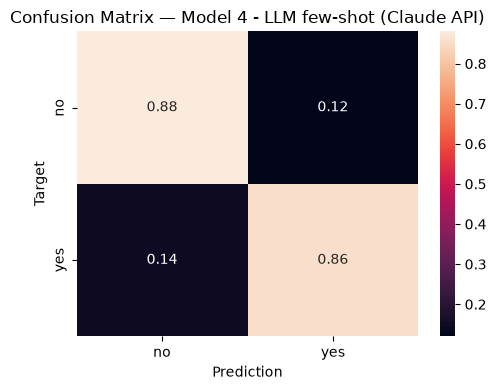

In [27]:
y_pred = (llm_scores > 0.5).astype(int)

results_model_4 = compute_metrics(
    y_val_eval, y_pred, llm_scores,
    'Model 4 - LLM few-shot (Claude API)',
    threshold=0.5
)

plot_confusion_matrix(y_val_eval, y_pred, 'Model 4 - LLM few-shot (Claude API)')

append_to_experiment_table(results_model_4)